# 1 Fourier Synthesis


## 1.1 Write a function a(n) that returns the coefficient $a_n$ corresponding to the given index n.

In [1]:
import numpy as np

def a(n):
    if n%2 == 0:
        return 0
    else:
        return 4 /((np.pi**2) * (n**2))

## 1.2 Using this function, plot the coefficients an for n ∈ [−10, 10]. Label the axes clearly and make sure that tick marks are shown only for valid values.

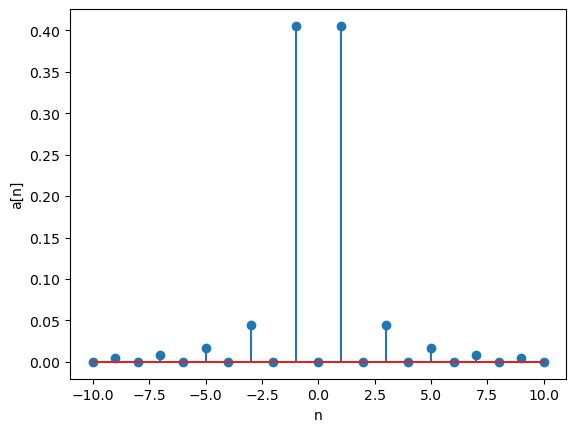

In [2]:
import matplotlib.pyplot as plt

n= np.arange(-10, 11)
anums=[]

for values in n:
    anums.append(a(values))

plt.figure()
plt.stem(n, anums)
plt.xlabel('n')
plt.ylabel('a[n]')
plt.show()


## 1.3 The truncated Fourier synthesis is given by $$\hat{f}(t, \omega_0, n_{\text{max}}) = \sum_{k=-n_{\text{max}}}^{n_{\text{max}}} a_k e^{jk\omega_0 t}$$ Obtain a simplified expression for $\hat{f}(t, \omega_0, n_{\text{max}}) $ in terms of trigonometric functions.

$$
\begin{aligned}
\hat{f}(t, \omega_0, n_{\text{max}}) &= \sum_{k=-n_{\text{max}}}^{n_{\text{max}}} a_k e^{jk\omega_0 t} \\
&= a_{-n_{\text{max}}} e^{-j n_{\text{max}} \omega_0 t} + a_{-(n_{\text{max}} - 1)} e^{-j (n_{\text{max}} -1)\omega_0 t} + ... + a_{n_{\text{max}} - 1} e^{j (n_{\text{max}} -1)\omega_0 t} + a_{n_{\text{max}}} e^{j n_{\text{max}} \omega_0 t} \\
&= (a_{-n_{\text{max}}} e^{-j n_{\text{max}} \omega_0 t} + a_{n_{\text{max}}} e^{j n_{\text{max}} \omega_0 t}) + ... + (a_{0} e^{-j 0 \omega_0 t} + a_0 e^{j 0 \omega_0 t})\\
\text{since }a_k=a_{-k} \\
&= a_{n_{\text{max}}}(e^{-j n_{\text{max}} \omega_0 t} + e^{j n_{\text{max}} \omega_0 t}) + ... + a_0 (e^{-j 0 \omega_0 t} + e^{j 0 \omega_0 t}) \\
&= 2 a_{n_{\text{max}}} cos(n_{\text{max}} \omega_0 t) + ... + 2 a_0 cos(0 \omega_0 t)\\
&= 2 \sum_{k = 0}^{n_{\text{max}}} a_k cos(k \omega_0 t)
\end{aligned}
$$


## 1.4 Write a function fhat(t, omega0, nmax) that returns the truncated Fourier synthesis for any array of time values t, fundamental angular frequency omega0, and truncation limit nmax.

In [3]:
def fhat(t, omega0, nmax):
    sum = 0
    for k in range(nmax+1):
        if a(k) == 0:
            continue
        else:
            sum += a(k) * np.cos(t * omega0 * k)
    return 2*sum

## 1.5 Using this function, plot on a single set of axes the truncated Fourier synthesis for T = 4 and $n_{max}$ = {1, 3, 5, 7, 9}. Show the range −2 ≤ t ≤ 2. Label the axes clearly.

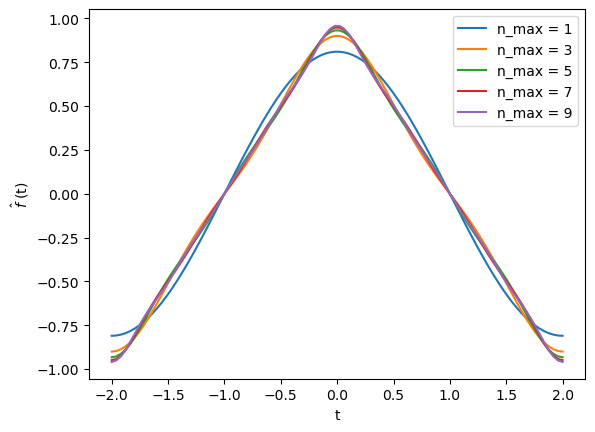

In [4]:
t = np.linspace(-2, 2, 100)
omega0 = np.pi / 2
nmax = [1, 3, 5, 7, 9]

plt.figure()

for n in nmax:
    label_text = f"n_max = {n}"
    func = fhat(t, omega0, n)
    plt.plot(t, func, label = label_text)

plt.legend()
plt.xlabel('t')
plt.ylabel('$\\hat{f}$ (t)')
plt.show()


# 2 Error Analysis

## 2.1  Write a function f(t) that returns the periodic function for any array of time values t, where all values of t can be assumed to lie within the prime interval. Plot the result.

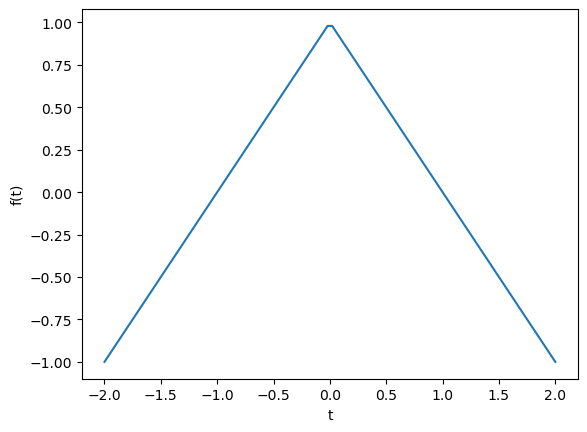

In [5]:
def f(t):
    if t>=0:
        return 1-t
    else:
        return 1+t

t = np.linspace(-2, 2, 100)
func_t = []
for numt in t:
    func_t.append(f(numt))

plt.figure()
plt.plot(t, func_t)
plt.xlabel('t')
plt.ylabel('f(t)')
plt.show()

## 2.2 Using this function, plot the error of the truncated Fourier synthesis, given by $\hat{f}$ (t, $n_{max}$) − f(t),over the range −2 ≤ t ≤ 2, for T = 4 and $n_{max}$ = {1, 3, 5, 7, 9}. Label the axes clearly

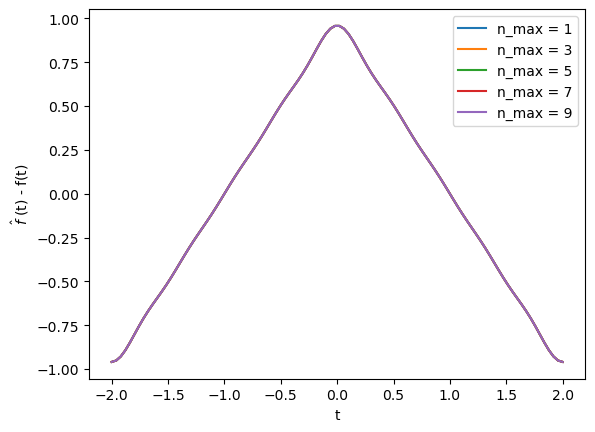

In [6]:
t = np.linspace(-2, 2, 100)
omega0 = np.pi / 2
nmax = [1, 3, 5, 7, 9]

plt.figure()

for n in nmax:
    label_text = f"n_max = {n}"
    error = fhat(t, omega0, n) - func_t
    plt.plot(t, func, label = label_text)

plt.legend()
plt.xlabel('t')
plt.ylabel('$\\hat{f}$ (t) - f(t)')
plt.show()

## 2.3 Write a function E(nmax) that returns the energy of the approximation error over one period, defined as $$E(n_{\text{max}}) = \int_T \left| \hat{f}(t, n_{\text{max}}) - f(t) \right|^2 \, dt.$$


In [7]:
def E(nmax):
    result = np.trapz((abs(fhat(t, omega0, nmax) - func_t)  ** 2), t)
    return result

## 2.4 Using this function, plot the energy of the approximation error against the number of coefficients, for 1 ≤ $n_{max}$ ≤ 20. Label the axes clearly, using a suitable scale for the y‐axis, and make sure that tick marks are shown only for valid values.

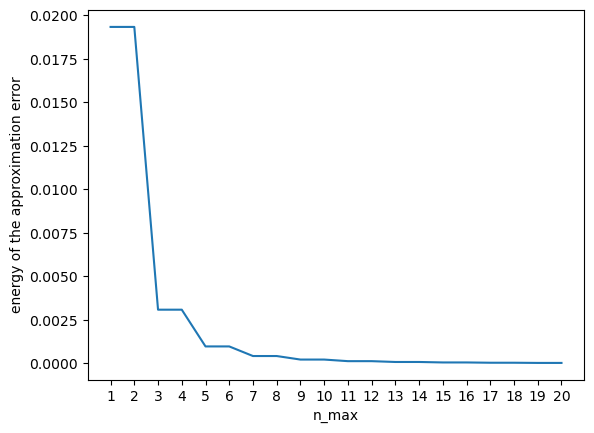

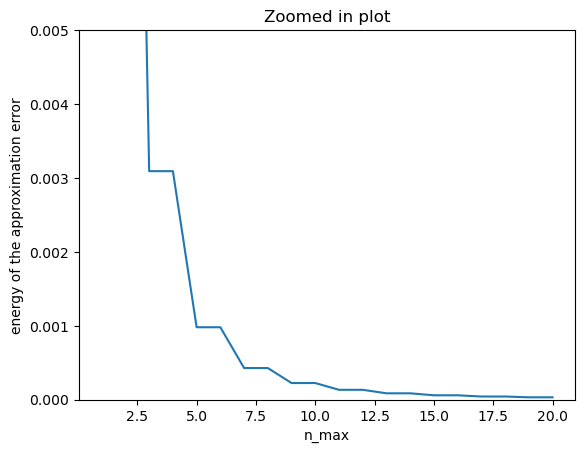

In [8]:
nrange = []
energy = []
for i in range(1,21):
    energy.append(E(i))
    nrange.append(i)
plt.figure()
plt.plot(nrange, energy)
plt.xlabel('n_max')
plt.ylabel('energy of the approximation error')
plt.xticks(np.linspace(1,20,20))
plt.show()

plt.figure()
plt.plot(nrange, energy)
plt.ylim(0, 0.0050)
plt.title('Zoomed in plot')
plt.xlabel('n_max')
plt.ylabel('energy of the approximation error')
plt.show()

## 2.5 Comment on the results obtained.

After we start taking into consideration values of n_max greater than 3 the energy starts to get closer to 0, this means that the fourier series representation gets closer and closer to the periodic function f(t). The error becoms negligable as more terms are added.